In [1]:
import os
import itertools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import arcpy
from arcpy.ia import *
from arcpy.ia import Clip as iaClip
from pystac_client import Client

In [2]:
# bounding box dla zbiornika Asprokremmos
bbox = [32.53, 34.724685, 32.578648, 34.762221] 

# zakres dat 
date_range = "2025-06-06T00:00:00Z/2026-06-01T23:59:59Z"

# zakresy dla zapytań STAC
date_range_old = "2025-06-01T00:00:00Z/2025-06-09T23:59:59Z"
date_range_new = "2026-06-01T00:00:00Z/2026-06-08T23:59:59Z"

# maksymalne pokrycie chmur
max_cloud_cover = 5

Tabela metadanych

In [3]:
# inicjalizacja klienta STAC (Earth Search AWS)
catalog = Client.open("https://earth-search.aws.element84.com/v1")

# słownik do przechowywania wyników wyszukiwania dla obu okresów
queries = {"scena_2025": date_range_old, "scena_2026": date_range_new}

all_assets_rows = []

# pętla iterująca po obu okresach czasowych
for period_name, date_range in queries.items():
    search = catalog.search(
        collections=["sentinel-2-l2a"],
        bbox=bbox,
        datetime=date_range,
        query={"eo:cloud_cover": {"lt": max_cloud_cover}},
        max_items=1,  # pobieramy 1 najlepsze zdjęcie
    )

    item = list(search.items())[0]

    print(
        f"{period_name}: znaleziona scena ID: {item.id}, data: {item.datetime}, zachmurzenie: {item.properties.get('eo:cloud_cover')}%\n"
    )

    # ekstrakcja metadanych assetów (pasm) dla znalezionej sceny
    for asset_key, asset in item.assets.items():
        extra = asset.extra_fields

        eo_bands = extra.get("eo:bands", [])
        raster_bands = extra.get("raster:bands", [])

        all_assets_rows.append(
            {
                "okres": period_name,
                "scene_id": item.id,
                "asset_key": asset_key,
                "title": asset.title,
                "media_type": asset.media_type,
                "href": asset.href,
                "eo_band_names": [b.get("name") for b in eo_bands],
                "eo_common_names": [
                    b.get("common_name") for b in eo_bands
                ],
                "eo_centers": [b.get("center_wavelength") for b in eo_bands],
                "raster_bands": raster_bands,
            }
        )

scena_2025: znaleziona scena ID: S2B_36SVD_20250606_1_L2A, data: 2025-06-06 08:40:36.295000+00:00, zachmurzenie: 0.047064%

scena_2026: znaleziona scena ID: S2C_36SVD_20260606_0_L2A, data: 2026-06-06 08:40:35.328000+00:00, zachmurzenie: 0.478668%



In [4]:
# tworzenie zbiorczego DataFrame
assets_df = pd.DataFrame(all_assets_rows)

# wyświetlenie odfiltrowanych, najważniejszych kolumn (dodana kolumna 'okres' i 'scene_id')
display_cols = [
    "okres",
    "scene_id",
    "asset_key",
    "title",
    "eo_band_names",
    "eo_common_names",
    "eo_centers",
    "media_type",
]

assets_df_filtered = assets_df[display_cols]
assets_df_filtered.head(10)

,okres,scene_id,asset_key,title,eo_band_names,eo_common_names,eo_centers,media_type
0,scena_2025,S2B_36SVD_20250606_1_L2A,aot,Aerosol optical thickness (AOT),[],[],[],image/tiff; application=geotiff; profile=cloud...
1,scena_2025,S2B_36SVD_20250606_1_L2A,blue,Blue - 10m,[B02],[blue],[0.49],image/tiff; application=geotiff; profile=cloud...
2,scena_2025,S2B_36SVD_20250606_1_L2A,cloud,Cloud Probabilities,[],[],[],image/jp2
3,scena_2025,S2B_36SVD_20250606_1_L2A,coastal,Coastal - 60m,[B01],[coastal],[0.443],image/tiff; application=geotiff; profile=cloud...
4,scena_2025,S2B_36SVD_20250606_1_L2A,granule_metadata,NaN,[],[],[],application/xml
5,scena_2025,S2B_36SVD_20250606_1_L2A,green,Green - 10m,[B03],[green],[0.56],image/tiff; application=geotiff; profile=cloud...
6,scena_2025,S2B_36SVD_20250606_1_L2A,nir,NIR 1 - 10m,[B08],[nir],[0.842],image/tiff; application=geotiff; profile=cloud...
7,scena_2025,S2B_36SVD_20250606_1_L2A,nir08,NIR 2 - 20m,[B8A],[nir08],[0.865],image/tiff; application=geotiff; profile=cloud...
8,scena_2025,S2B_36SVD_20250606_1_L2A,nir09,NIR 3 - 60m,[B09],[nir09],[0.945],image/tiff; application=geotiff; profile=cloud...
9,scena_2025,S2B_36SVD_20250606_1_L2A,product_metadata,NaN,[],[],[],application/xml


In [5]:
query_old = {
    "collections": ["sentinel-2-l2a"],
    "bbox": bbox,
    "query": {"eo:cloud_cover": {"lt": max_cloud_cover}},
    "datetime": date_range_old,
    "limit": 1
}

query_new = {
    "collections": ["sentinel-2-l2a"],
    "bbox": bbox,
    "query": {"eo:cloud_cover": {"lt": max_cloud_cover}},
    "datetime": date_range_new,
    "limit": 1
}

rc_old = arcpy.ia.RasterCollection.fromSTACAPI("https://earth-search.aws.element84.com/v1", 
                                               query=query_old, 
                                               attribute_dict={"Name":"id", "StdTime":"datetime"})
rc_new = arcpy.ia.RasterCollection.fromSTACAPI("https://earth-search.aws.element84.com/v1", 
                                               query=query_new, 
                                               attribute_dict={"Name":"id", "StdTime":"datetime"})

raster_old = rc_old[0]["Raster"]
raster_new = rc_new[0]["Raster"]

Przycięcie do BBOX

In [6]:
sr_wgs84 = arcpy.SpatialReference(4326)
sr_raster = raster_old.spatialReference

pt_min = arcpy.Point(bbox[0], bbox[1])
pt_max = arcpy.Point(bbox[2], bbox[3])

pt_min_proj = arcpy.PointGeometry(pt_min, sr_wgs84).projectAs(sr_raster)
pt_max_proj = arcpy.PointGeometry(pt_max, sr_wgs84).projectAs(sr_raster)

extent_proj = arcpy.Extent(
    pt_min_proj.firstPoint.X, pt_min_proj.firstPoint.Y,
    pt_max_proj.firstPoint.X, pt_max_proj.firstPoint.Y,
    spatial_reference=sr_raster,
)

clipped_old = iaClip(raster_old, extent_proj)
clipped_new = iaClip(raster_new, extent_proj)

Wyciągnięcie pasm

In [ ]:
# Scena 2025 - Wyciągamy konkretne pasma na podstawie ich numerów (od 1)
green_raster_old = arcpy.management.MakeRasterLayer(clipped_old, "green_2025", band_index=[6])
nir_raster_old   = arcpy.management.MakeRasterLayer(clipped_old, "nir_2025", band_index=[7])
red_raster_old   = arcpy.management.MakeRasterLayer(clipped_old, "red_2025", band_index=[11])
blue_raster_old  = arcpy.management.MakeRasterLayer(clipped_old, "blue_2025", band_index=[2])

# Scena 2026
green_raster_new = arcpy.management.MakeRasterLayer(clipped_new, "green_2026", band_index=[6])
nir_raster_new   = arcpy.management.MakeRasterLayer(clipped_new, "nir_2026", band_index=[7])
red_raster_new   = arcpy.management.MakeRasterLayer(clipped_new, "red_2026", band_index=[11])
blue_raster_new  = arcpy.management.MakeRasterLayer(clipped_new, "blue_2026", band_index=[2])

Konwersja do NumPy

In [ ]:
# konwersja całych wyciętych rastrów do jednej macierzy NumPy
# najpierw konwertujemy do czystych floatów, zachowując strukturę (Bands, Y, X)
arr_old_full = arcpy.RasterToNumPyArray(clipped_old, nodata_to_value=0).astype(float)
arr_new_full = arcpy.RasterToNumPyArray(clipped_new, nodata_to_value=0).astype(float)

# wyciąganie konkretnych pasm bezpośrednio z osi kanałów macierzy NumPy (indeksowanie od 0)
blue_old  = arr_old_full[1]
green_old = arr_old_full[5]
nir_old   = arr_old_full[6]
red_old   = arr_old_full[10]

blue_new  = arr_new_full[1]
green_new = arr_new_full[5]
nir_new   = arr_new_full[6]
red_new   = arr_new_full[10]

C:\Users\znozk\AppData\Local\Temp\ipykernel_17068\1574377976.py:29: RuntimeWarning: invalid value encountered in divide
  ndwi_old = np.where(denom_old == 0, -1, (green_old - nir_old) / denom_old)
C:\Users\znozk\AppData\Local\Temp\ipykernel_17068\1574377976.py:30: RuntimeWarning: invalid value encountered in divide
  ndwi_new = np.where(denom_new == 0, -1, (green_new - nir_new) / denom_new)


NDWI

In [20]:
# pracujemy na surowych wartościach (skalowanie /10000 nie zmienia wyniku dzielenia)
denom_old = green_old + nir_old
denom_new = green_new + nir_new

ndwi_old = np.where(denom_old == 0, -1, (green_old - nir_old) / denom_old)
ndwi_new = np.where(denom_new == 0, -1, (green_new - nir_new) / denom_new)

# tworzenie binarnej maski wody
water_threshold = 0.6
water_mask_old = ndwi_old > water_threshold
water_mask_new = ndwi_new > water_threshold

# procent powierzchni wody w kadrze (tylko dla obszarów, gdzie są dane > 0)
valid_old = denom_old > 0
water_pct_old = (np.sum(water_mask_old & valid_old) / np.sum(valid_old)) * 100 if np.sum(valid_old) > 0 else 0

valid_new = denom_new > 0
water_pct_new = (np.sum(water_mask_new & valid_new) / np.sum(valid_new)) * 100 if np.sum(valid_new) > 0 else 0

# skalujemy dzieląc przez 3000.0 (wartość odbicia 0.3), co idealnie balansuje jasność Sentinel-2
rgb_old = np.stack([red_old, green_old, blue_old], axis=-1) / 3000.0
rgb_new = np.stack([red_new, green_new, blue_new], axis=-1) / 3000.0

# obcinamy wartości do bezpiecznego przedziału [0, 1]
rgb_old = np.clip(rgb_old, 0, 1)
rgb_new = np.clip(rgb_new, 0, 1)

C:\Users\znozk\AppData\Local\Temp\ipykernel_17068\1438644912.py:5: RuntimeWarning: invalid value encountered in divide
  ndwi_old = np.where(denom_old == 0, -1, (green_old - nir_old) / denom_old)
C:\Users\znozk\AppData\Local\Temp\ipykernel_17068\1438644912.py:6: RuntimeWarning: invalid value encountered in divide
  ndwi_new = np.where(denom_new == 0, -1, (green_new - nir_new) / denom_new)


Wykres

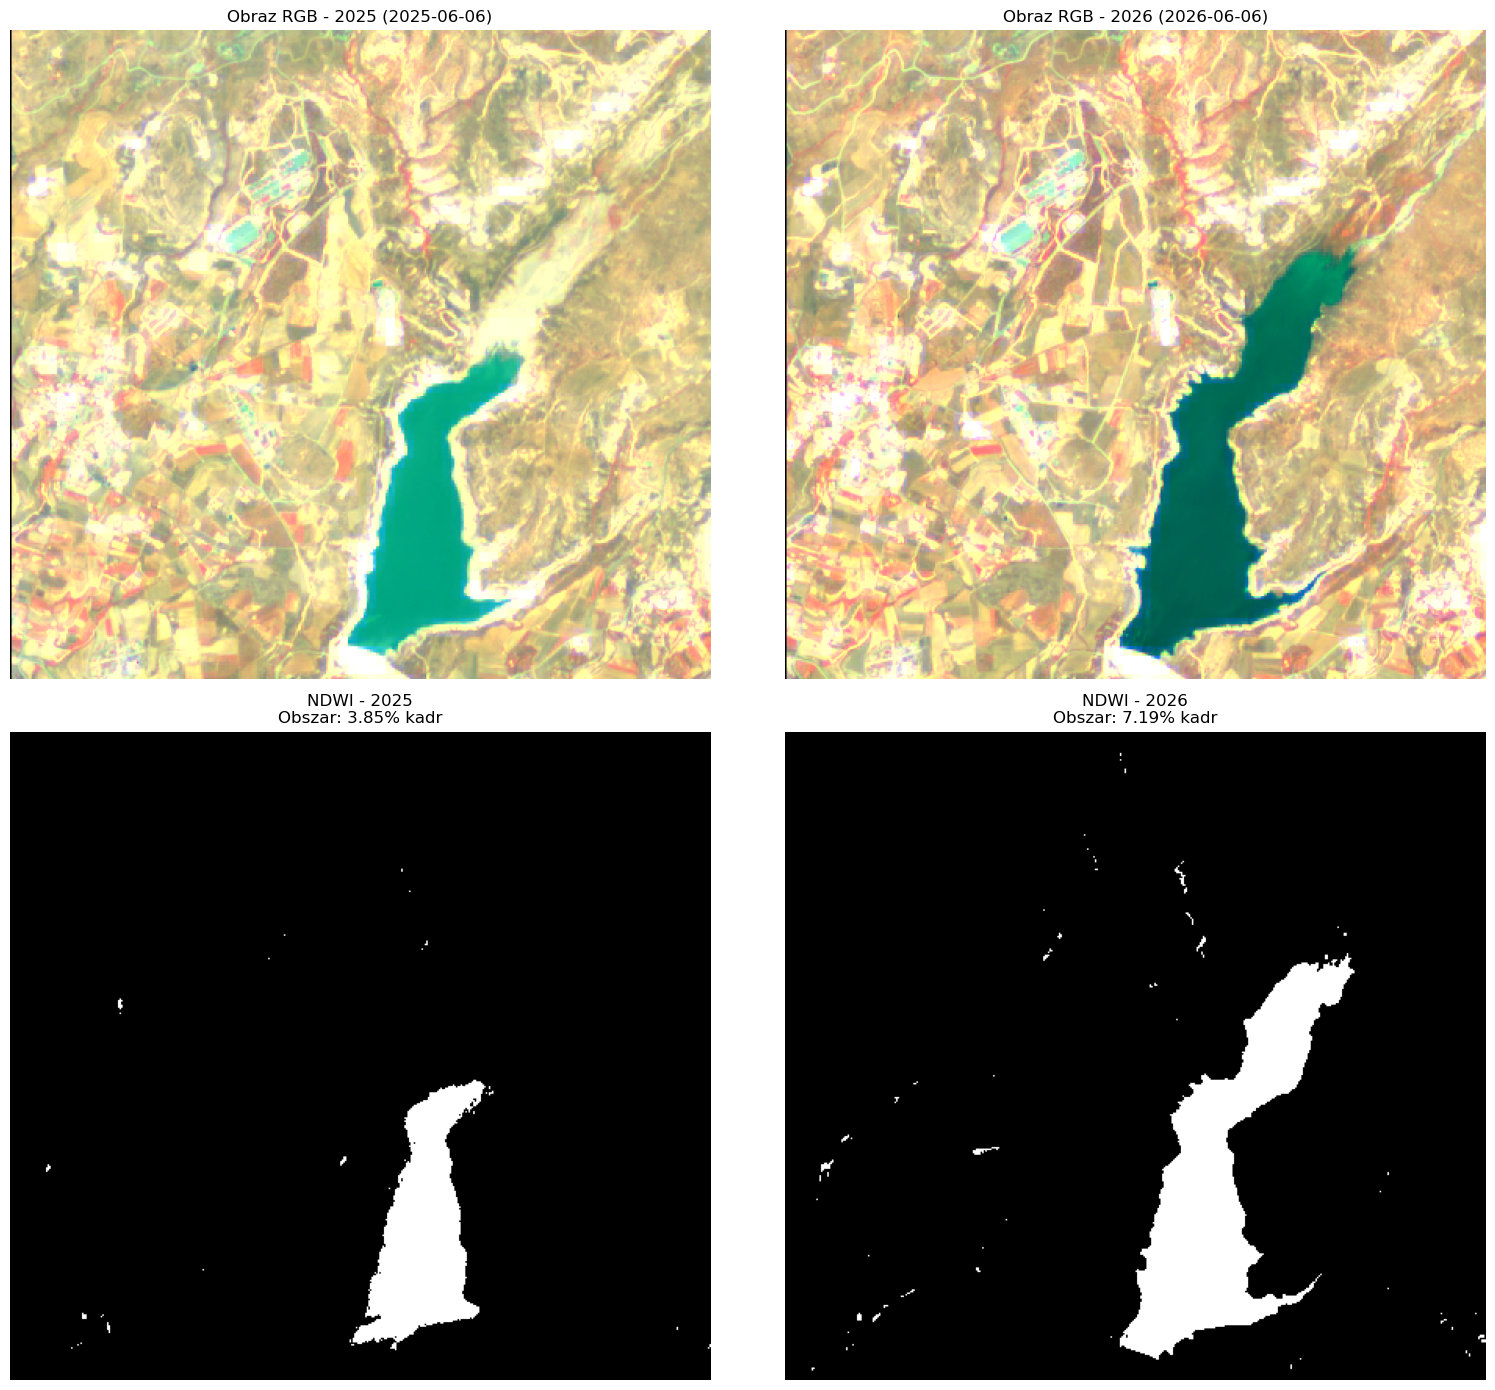

In [21]:
date_old = str(rc_old[0]["StdTime"])[:10]
date_new = str(rc_new[0]["StdTime"])[:10]

fig, axes = plt.subplots(2, 2, figsize=(16, 14))

# RGB
axes[0, 0].imshow(rgb_old)
axes[0, 0].set_title(f"Obraz RGB - 2025 ({date_old})")
axes[0, 0].axis("off")

axes[0, 1].imshow(rgb_new)
axes[0, 1].set_title(f"Obraz RGB - 2026 ({date_new})")
axes[0, 1].axis("off")

# NDWI
axes[1, 0].imshow(water_mask_old, cmap="grey")
axes[1, 1].imshow(water_mask_old, cmap="grey")
axes[1, 0].set_title(f"NDWI - 2025\nObszar: {water_pct_old:.2f}% kadr")
axes[1, 0].axis("off")

axes[1, 1].imshow(water_mask_new, cmap="grey")
axes[1, 1].set_title(f"NDWI - 2026\nObszar: {water_pct_new:.2f}% kadr")
axes[1, 1].axis("off")

plt.tight_layout()
plt.show()